In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp1_group"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedGroupKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
groups = df['lesion_id'].values 

# BERUBAH: Menggunakan StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
# CELL 4: MODEL ARCHITECTURE (ConvNeXt + SE Attention) [REVISI DIMENSI]
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ConvNeXt_SE_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_SE_Attention, self).__init__()
        # Load pre-trained ConvNeXt-Tiny
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        
        # Ekstrak feature extractor
        self.features = convnext.features
        
        # Dimensi output terakhir dari ConvNeXt-Tiny adalah 768
        self.se_block = SEBlock(channel=768)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # REVISI DI SINI: Flatten diletakkan sebelum LayerNorm
        self.classifier = nn.Sequential(
            nn.Flatten(1),                     # Ubah dari (32, 768, 1, 1) menjadi (32, 768)
            nn.LayerNorm(768, eps=1e-6),       # Sekarang LayerNorm menerima bentuk yang benar
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.se_block(x) 
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Test inisialisasi model
model_test = ConvNeXt_SE_Attention().to(device)
print(f"Total parameter: {sum(p.numel() for p in model_test.parameters())}")

Total parameter: 27899239


In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Simpan metrik
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Simpan model terbaik (.pth)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp1_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa hardware
    end_time = time.time()
    training_time = end_time - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # Dalam MB
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp1_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp1_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp1_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp1_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp1_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp1_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 1: ConvNeXt + SE Attention + Focal Loss
Menyimpan di folder: results_exp1_group

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.4055 Acc: 0.7494 | Val Loss: 0.2799 Acc: 0.8024
Epoch 2/50 - Train Loss: 0.2048 Acc: 0.8405 | Val Loss: 0.2505 Acc: 0.8198
Epoch 3/50 - Train Loss: 0.1391 Acc: 0.8799 | Val Loss: 0.2231 Acc: 0.8327
Epoch 4/50 - Train Loss: 0.1068 Acc: 0.9038 | Val Loss: 0.2890 Acc: 0.8217
Epoch 5/50 - Train Loss: 0.1427 Acc: 0.8815 | Val Loss: 0.2660 Acc: 0.8357
Epoch 6/50 - Train Loss: 0.0603 Acc: 0.9400 | Val Loss: 0.2318 Acc: 0.8496
Epoch 7/50 - Train Loss: 0.0412 Acc: 0.9566 | Val Loss: 0.2392 Acc: 0.8515
Epoch 8/50 - Train Loss: 0.0375 Acc: 0.9624 | Val Loss: 0.2578 Acc: 0.8476
Epoch 9/50 - Train Loss: 0.0273 Acc: 0.9703 | Val Loss: 0.2658 Acc: 0.8381
Epoch 10/50 - Train Loss: 0.0242 Acc: 0.9770 | Val Loss: 0.3493 Acc: 0.8371
Epoch 11/50 - Train Loss: 0.1232 Acc: 0.9029 | Val Loss: 0.3359 Acc: 0.7716
Epoch 12/50 - Train Loss: 0.0594 Acc: 0.9439 | Val

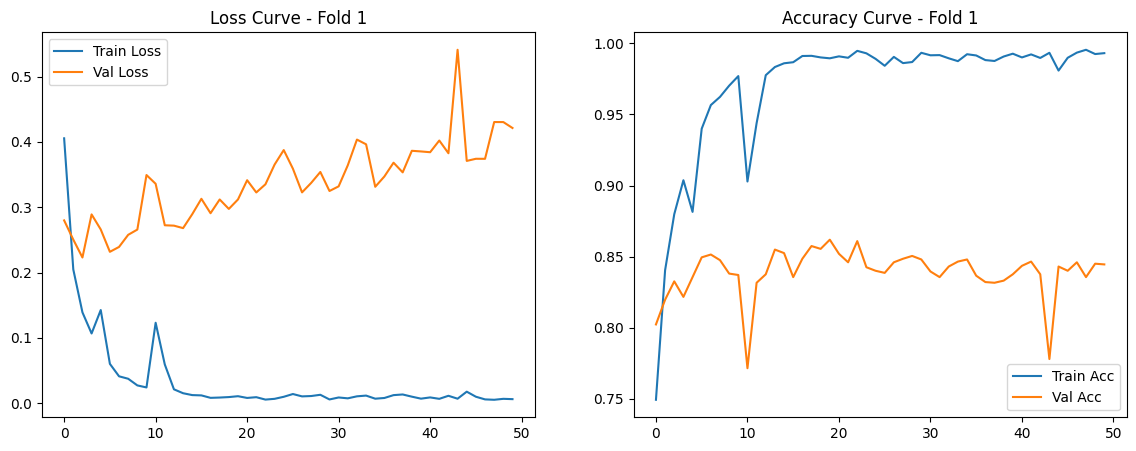

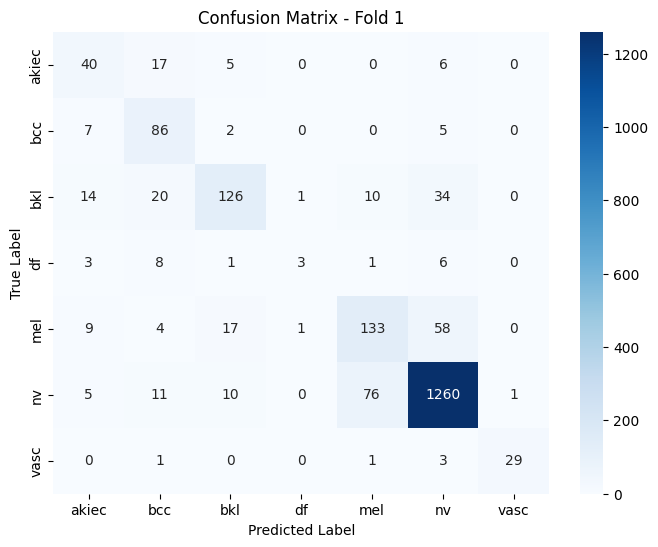

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp1_group

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4006 Acc: 0.7466 | Val Loss: 0.2339 Acc: 0.8082
Epoch 2/50 - Train Loss: 0.2139 Acc: 0.8356 | Val Loss: 0.2054 Acc: 0.8358
Epoch 3/50 - Train Loss: 0.1454 Acc: 0.8748 | Val Loss: 0.2265 Acc: 0.8403
Epoch 4/50 - Train Loss: 0.1140 Acc: 0.8964 | Val Loss: 0.1964 Acc: 0.8563
Epoch 5/50 - Train Loss: 0.0703 Acc: 0.9298 | Val Loss: 0.2086 Acc: 0.8483
Epoch 6/50 - Train Loss: 0.0546 Acc: 0.9433 | Val Loss: 0.2019 Acc: 0.8588
Epoch 7/50 - Train Loss: 0.0409 Acc: 0.9563 | Val Loss: 0.2133 Acc: 0.8488
Epoch 8/50 - Train Loss: 0.0439 Acc: 0.9580 | Val Loss: 0.1970 Acc: 0.8698
Epoch 9/50 - Train Loss: 0.0315 Acc: 0.9665 | Val Loss: 0.2292 Acc: 0.8598
Epoch 10/50 - Train Loss: 0.0272 Acc: 0.9723 | Val Loss: 0.2359 Acc: 0.8503
Epoch 11/50 - Train Loss: 0.0211 Acc: 0.9744 | Val Loss: 0.2320 Acc: 0.8683
Epoch 12/50 - Train Loss: 0.0282 Acc: 0.9718 | Val Loss: 0.2799 A

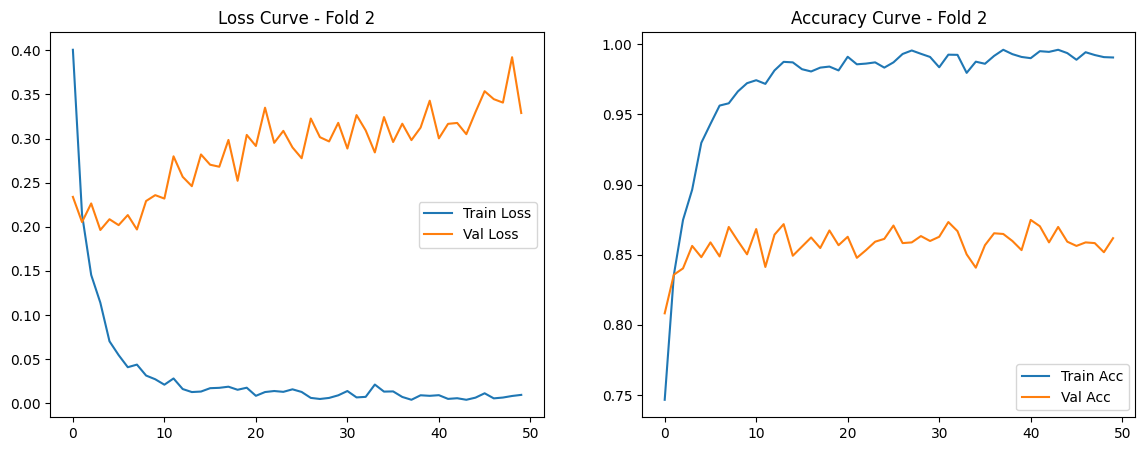

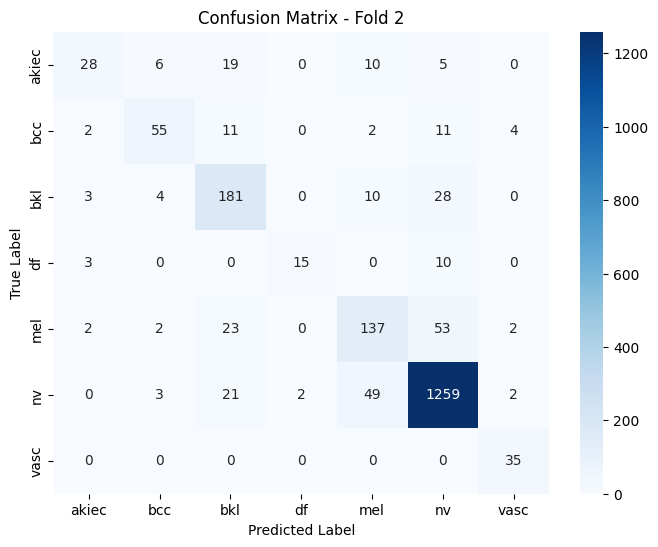

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp1_group

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.4121 Acc: 0.7440 | Val Loss: 0.2806 Acc: 0.8055
Epoch 2/50 - Train Loss: 0.2327 Acc: 0.8211 | Val Loss: 0.2538 Acc: 0.7871
Epoch 3/50 - Train Loss: 0.1593 Acc: 0.8702 | Val Loss: 0.2058 Acc: 0.8398
Epoch 4/50 - Train Loss: 0.1011 Acc: 0.9082 | Val Loss: 0.1968 Acc: 0.8522
Epoch 5/50 - Train Loss: 0.0751 Acc: 0.9285 | Val Loss: 0.2143 Acc: 0.8194
Epoch 6/50 - Train Loss: 0.0601 Acc: 0.9397 | Val Loss: 0.2187 Acc: 0.8512
Epoch 7/50 - Train Loss: 0.0383 Acc: 0.9589 | Val Loss: 0.2532 Acc: 0.8378
Epoch 8/50 - Train Loss: 0.0578 Acc: 0.9477 | Val Loss: 0.2863 Acc: 0.8428
Epoch 9/50 - Train Loss: 0.0286 Acc: 0.9721 | Val Loss: 0.2280 Acc: 0.8473
Epoch 10/50 - Train Loss: 0.0227 Acc: 0.9745 | Val Loss: 0.2593 Acc: 0.8527
Epoch 11/50 - Train Loss: 0.0220 Acc: 0.9766 | Val Loss: 0.2628 Acc: 0.8507
Epoch 12/50 - Train Loss: 0.0176 Acc: 0.9795 | Val Loss: 0.2959 A

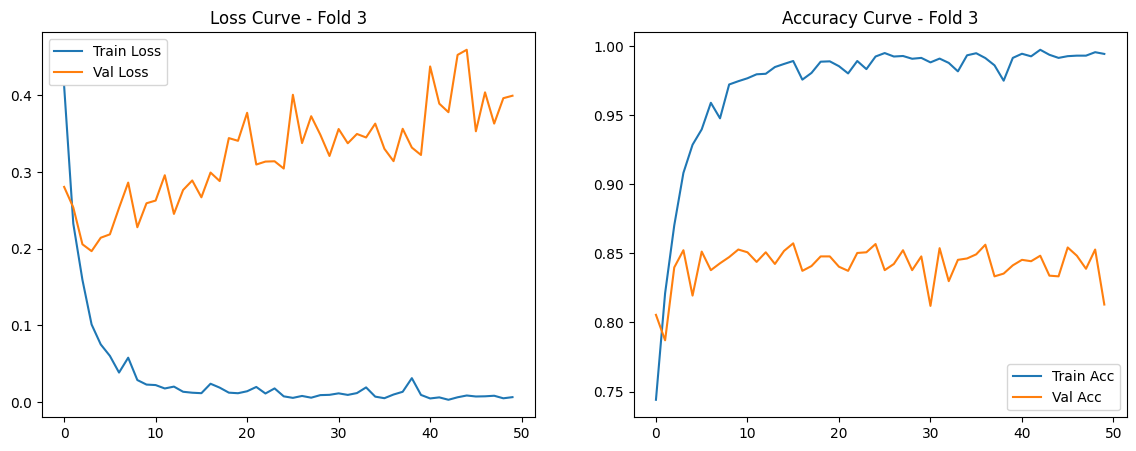

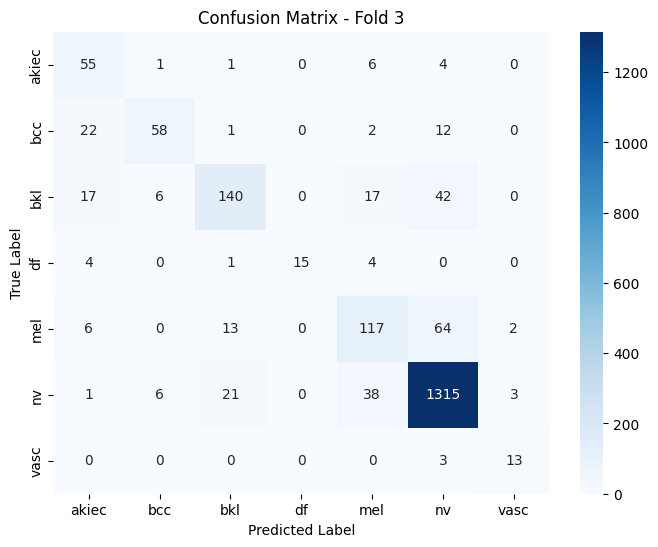

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp1_group

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.3745 Acc: 0.7598 | Val Loss: 0.2991 Acc: 0.7557
Epoch 2/50 - Train Loss: 0.1993 Acc: 0.8443 | Val Loss: 0.2185 Acc: 0.8277
Epoch 3/50 - Train Loss: 0.1362 Acc: 0.8880 | Val Loss: 0.2160 Acc: 0.8347
Epoch 4/50 - Train Loss: 0.0968 Acc: 0.9126 | Val Loss: 0.2527 Acc: 0.8287
Epoch 5/50 - Train Loss: 0.0697 Acc: 0.9319 | Val Loss: 0.2619 Acc: 0.8267
Epoch 6/50 - Train Loss: 0.0570 Acc: 0.9438 | Val Loss: 0.2469 Acc: 0.8267
Epoch 7/50 - Train Loss: 0.0368 Acc: 0.9588 | Val Loss: 0.2695 Acc: 0.8163
Epoch 8/50 - Train Loss: 0.0906 Acc: 0.9200 | Val Loss: 0.2411 Acc: 0.8337
Epoch 9/50 - Train Loss: 0.0308 Acc: 0.9703 | Val Loss: 0.2490 Acc: 0.8436
Epoch 10/50 - Train Loss: 0.0262 Acc: 0.9731 | Val Loss: 0.2748 Acc: 0.8416
Epoch 11/50 - Train Loss: 0.0198 Acc: 0.9790 | Val Loss: 0.2661 Acc: 0.8431
Epoch 12/50 - Train Loss: 0.0171 Acc: 0.9814 | Val Loss: 0.2761 A

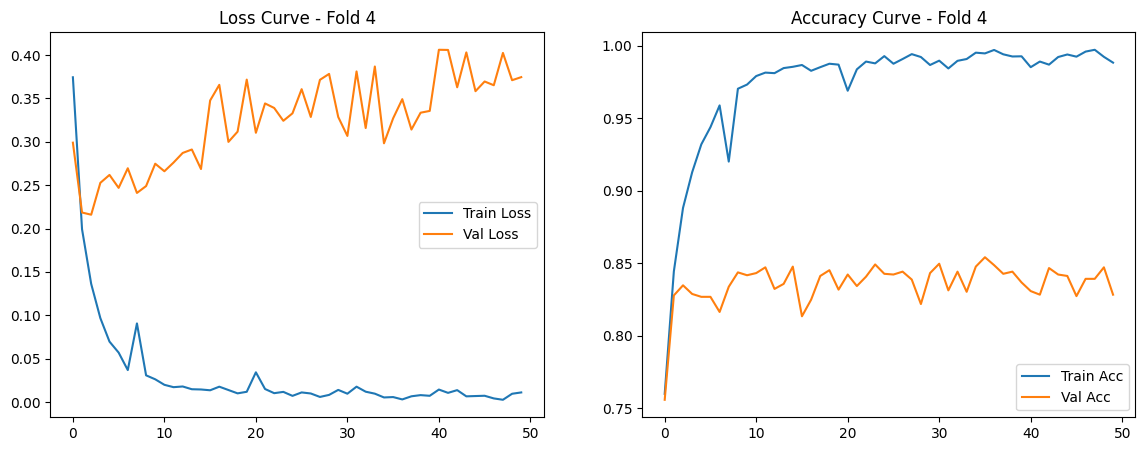

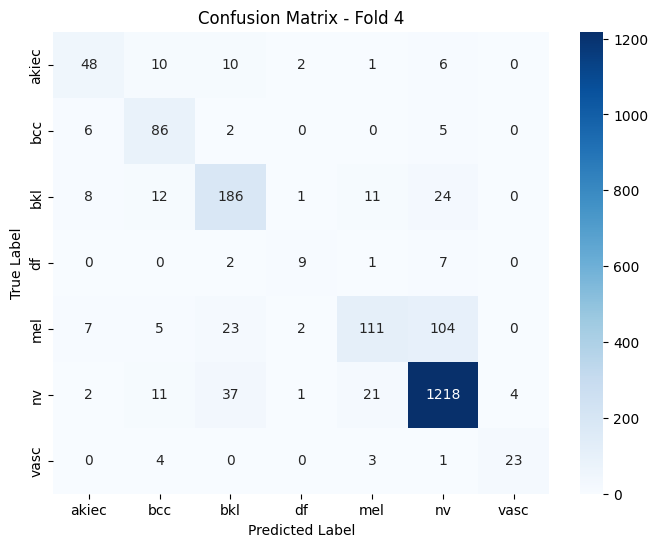

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp1_group

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.3913 Acc: 0.7513 | Val Loss: 0.2346 Acc: 0.8263
Epoch 2/50 - Train Loss: 0.1980 Acc: 0.8488 | Val Loss: 0.2437 Acc: 0.8141
Epoch 3/50 - Train Loss: 0.1314 Acc: 0.8829 | Val Loss: 0.2160 Acc: 0.8379
Epoch 4/50 - Train Loss: 0.0903 Acc: 0.9170 | Val Loss: 0.2300 Acc: 0.8505
Epoch 5/50 - Train Loss: 0.0711 Acc: 0.9306 | Val Loss: 0.2481 Acc: 0.8449
Epoch 6/50 - Train Loss: 0.0505 Acc: 0.9482 | Val Loss: 0.2409 Acc: 0.8586
Epoch 7/50 - Train Loss: 0.0364 Acc: 0.9610 | Val Loss: 0.2322 Acc: 0.8515
Epoch 8/50 - Train Loss: 0.0386 Acc: 0.9602 | Val Loss: 0.2564 Acc: 0.8591
Epoch 9/50 - Train Loss: 0.0306 Acc: 0.9696 | Val Loss: 0.2707 Acc: 0.8626
Epoch 10/50 - Train Loss: 0.0221 Acc: 0.9790 | Val Loss: 0.2805 Acc: 0.8460
Epoch 11/50 - Train Loss: 0.0200 Acc: 0.9782 | Val Loss: 0.2829 Acc: 0.8561
Epoch 12/50 - Train Loss: 0.0196 Acc: 0.9787 | Val Loss: 0.2969 A

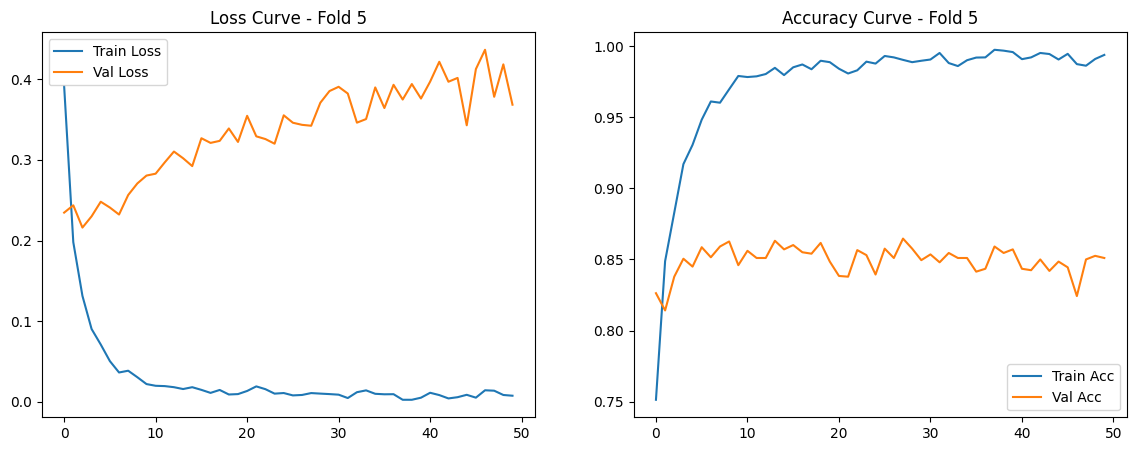

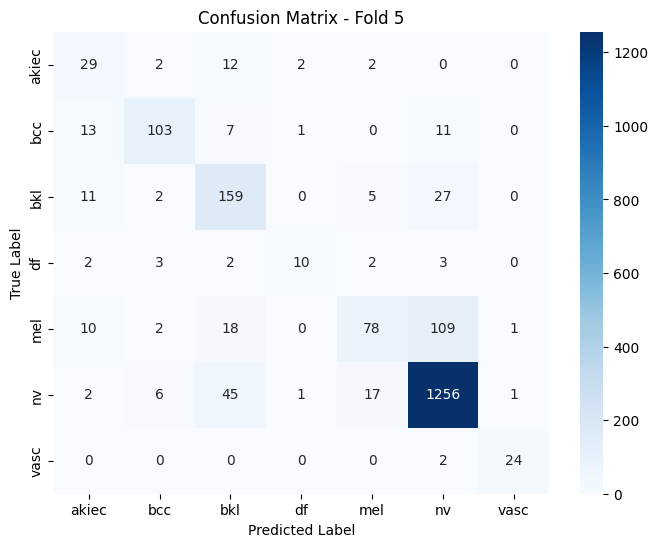

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp1_group

ALHAMDULILLAH, EKSPERIMEN 1 SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [7]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 1: ConvNeXt + SE Attention + Focal Loss")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_SE_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 1 SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [8]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
results_path = "results_exp1_group"
csv_files = glob.glob(os.path.join(results_path, "exp1_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 1 (STATISTIK Group 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP1_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP1_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 1 (STATISTIK Group 5-FOLD)
Mean Accuracy : 0.8427 ± 0.0108
Mean Macro F1 : 0.7051 ± 0.0314
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.576473,0.612259,0.574641
bcc,0.746481,0.749847,0.735353
bkl,0.730616,0.718831,0.719065
df,0.759328,0.445062,0.548617
mel,0.679267,0.520430,0.577565
nv,0.907517,0.940798,0.923771
vasc,0.855554,0.866091,0.856914
macro avg,0.750748,0.693331,0.705132
weighted avg,0.842757,0.842746,0.837374



[INFO] Laporan final telah disimpan di: results_exp1_group/EXP1_FINAL_SUMMARY_STATISTICS.csv
